# 🧬 Model Development – Immunotherapy Response Prediction
## Hackathon DIGPHAT – PharmacogenomicDay

**Use Case:** Multi-modal prediction of Immunotherapy response for ccRCC patients with follow-up post-Immune Checkpoint Blockade (ICB).

In this notebook we will:
1. Explore & integrate five omics/clinical modalities
2. Define the clinical outcome (RECIST response)
3. Preprocess each data modality (leakage-controlled)
4. Engineer features & reduce dimensionality
5. Train and evaluate multiple ML classifiers
6. Save the best model & preprocessing artifacts for the **Deployment Notebook**

In [2]:
import pandas as pd
import numpy as np
import os, warnings, joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    make_scorer, f1_score, balanced_accuracy_score,
    matthews_corrcoef, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import miceforest as mf

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed – XGBoost model will be skipped.")

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
print("All imports OK ✅")

All imports OK ✅


---
# 1. Objective & Clinical Question

**Clinical question:** Can we predict RECIST response (CR/PR vs SD/PD) to immunotherapy from multi-modal patient data?

| Item | Detail |
|------|--------|
| Tumor type | Clear-cell Renal Cell Carcinoma (ccRCC) |
| Treatment | Immune Checkpoint Blockade (Nivolumab / Ipilimumab) |
| Outcome | Binary RECIST: **Responder** (CR/PR) vs **Non-Responder** (SD/PD) |
| Sites | Primary + metastatic samples |

---
# 2. Dataset Overview

## 2.1 Modalities

| # | Modality | File | Description |
|---|----------|------|-------------|
| 1 | **Clinical** | `clinical_data.csv` | Demographics, treatment, tumour characteristics, RECIST |
| 2 | **Genomic** | `genomic_data.csv` | Somatic mutations & copy-number alterations |
| 3 | **Immune deconvolution** | `cell_deconvolution.csv` | CIBERSORTx cell-type proportions from bulk RNA-seq |
| 4 | **Pathway scores** | `ssgsea.csv` | ssGSEA scores for 50 Hallmark pathways (GSEAPy) |
| 5 | **Transcriptomic** | `transcriptomic_data.csv` | Gene-level TPM expression (~40 k genes) |

In [3]:
# ── Load all five modalities ──────────────────────────────────────────────────
clinical_df       = pd.read_csv('Data/clinical_data.csv')
genomic_df        = pd.read_csv('Data/genomic_data.csv')
deconv_df         = pd.read_csv('Data/cell_deconvolution.csv')
ssgsea_df         = pd.read_csv('Data/ssgsea.csv')
print("Loading transcriptomic data (this may take a moment)...")
transcriptomic_df = pd.read_csv('Data/transcriptomic_data.csv.gz')

for name, df in [('Clinical', clinical_df), ('Genomic', genomic_df),
                 ('Deconvolution', deconv_df), ('ssGSEA', ssgsea_df),
                 ('Transcriptomic', transcriptomic_df)]:
    print(f"{name:15s}  →  {df.shape[0]} patients × {df.shape[1]} features")

Loading transcriptomic data (this may take a moment)...
Clinical         →  311 patients × 11 features
Genomic          →  311 patients × 34 features
Deconvolution    →  311 patients × 27 features
ssGSEA           →  311 patients × 51 features
Transcriptomic   →  311 patients × 40935 features


In [4]:
# ── Quick look at each modality ───────────────────────────────────────────────
for name, df in [('Clinical', clinical_df), ('Genomic', genomic_df),
                 ('Deconvolution', deconv_df), ('ssGSEA', ssgsea_df),
                 ('Transcriptomic', transcriptomic_df)]:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    display(df.head(3))


  Clinical


,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD
1,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,67.0,FAVORABLE,No,No,2.0,PRIMARY,PR
2,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR



  Genomic


,Patient_ID,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF
1,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,MUT,MUT,MUT,MUT,WT,WT,MUT,MUT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT
2,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,MUT,MUT,MUT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,MUT,WT,WT



  Deconvolution


,Patient_ID,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.046327,0.086641,0.015842,0.185357,0.0,0.204351,0.022605,0.050186,0.009508,...,0.042027,0.021309,0.057458,0.000000,0.009780,0.053686,0,0.923779,0.650795,1.274922
1,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,0.069574,0.066311,0.011640,0.094022,0.0,0.192493,0.026367,0.093081,0.000000,...,0.051978,0.042653,0.095057,0.013068,0.001785,0.032963,0,0.940515,0.657605,1.294824
2,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.069083,0.050311,0.035438,0.101136,0.0,0.179168,0.035013,0.087914,0.000000,...,0.023344,0.019054,0.094429,0.000000,0.000000,0.075189,0,0.917443,0.667743,1.304494



  ssGSEA


,Patient_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,EA595454,0.645208,0.613143,0.640741,0.544471,0.477824,0.356894,0.653818,0.393865,0.589824,...,0.792464,0.729333,0.128080,0.670299,0.571636,0.717934,0.662968,0.512491,0.432010,0.477736
1,EA595455,0.730727,0.460351,0.673872,0.615952,0.518616,0.347035,0.641102,0.454217,0.659935,...,0.809339,0.752864,0.136680,0.686237,0.539509,0.764915,0.683743,0.542750,0.444790,0.557659
2,EA595473,0.745334,0.481716,0.692472,0.656193,0.583043,0.523270,0.671667,0.518503,0.672382,...,0.821810,0.773135,0.139733,0.745215,0.604999,0.734874,0.713620,0.574449,0.514951,0.629333



  Transcriptomic


,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,22.45228,34.75424,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
1,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,27.91941,34.70075,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,34.67436,34.35974,33.35211,34.23558,34.75711,21.13002,33.69635,33.57917,21.26386,33.96374
2,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,26.08813,33.57834,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667


## 2.2 Cohort Description & Missing Data

In [5]:
# ── Cohort summary ────────────────────────────────────────────────────────────
print(f"Total patients: {len(clinical_df)}")
print(f"\nORR distribution:")
print(clinical_df['ORR'].value_counts().to_string())
print(f"\nCohorts: {clinical_df['Cohort'].unique()}")
print(f"Treatment arms: {clinical_df['Arm'].unique()}")

Total patients: 311

ORR distribution:
ORR
SD      131
PD      106
NE       30
CRPR     30
PR       13
CR        1

Cohorts: ['CM-010' 'CM-025' 'CM-009']
Treatment arms: ['NIVOLUMAB' 'EVEROLIMUS']


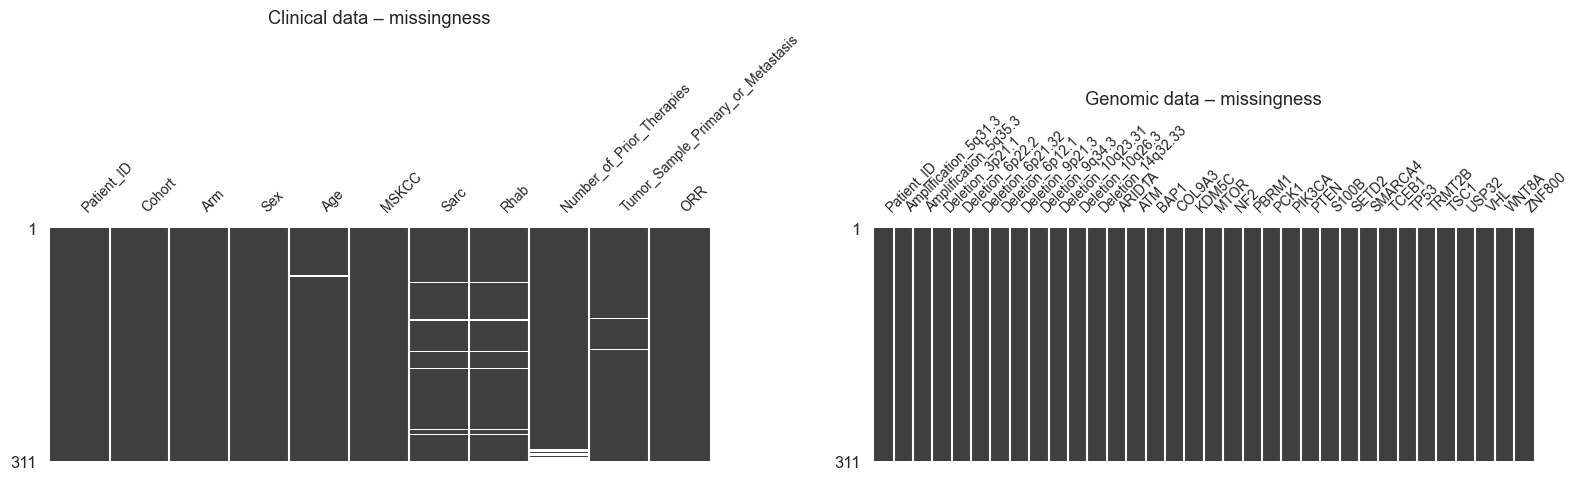

In [52]:
# ── Missing-data heatmap (clinical + genomic) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(clinical_df, ax=axes[0], sparkline=False, fontsize=10)
axes[0].set_title('Clinical data – missingness')
msno.matrix(genomic_df.iloc[:, :34], ax=axes[1], sparkline=False, fontsize=10)
axes[1].set_title('Genomic data – missingness')
plt.tight_layout()
plt.show()

---
# 3. Outcome Definition

## 3.1 RECIST Mapping

We define a **binary** outcome for immunotherapy response:
- **1 (Responder):** CR (Complete Response), PR (Partial Response), CRPR
- **0 (Non-Responder):** SD (Stable Disease), PD (Progressive Disease)

> **NE (Not Evaluable)** patients are excluded because their treatment response
> could not be assessed according to RECIST criteria (e.g. early dropout,
> missing imaging, or protocol deviation). Including them would introduce
> noise and reduce the reliability of the predictive model.

Dropped 30 NE (Not Evaluable) patients — cannot assess RECIST response
Remaining: 281 patients



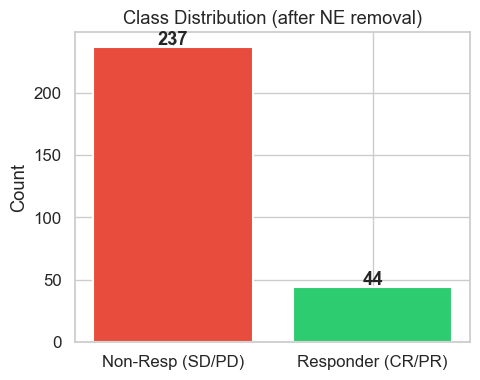

Responders: 44  |  Non-Responders: 237  |  Ratio: 1:5.4


In [6]:
# ── Map ORR → binary response ─────────────────────────────────────────────────
response_map = {'CR': 1, 'PR': 1, 'CRPR': 1, 'SD': 0, 'PD': 0}
clinical_df['Response'] = clinical_df['ORR'].map(response_map)

# Drop NE patients
n_before = len(clinical_df)
clinical_df = clinical_df.dropna(subset=['Response']).reset_index(drop=True)
n_ne = n_before - len(clinical_df)
clinical_df['Response'] = clinical_df['Response'].astype(int)
print(f"Dropped {n_ne} NE (Not Evaluable) patients — cannot assess RECIST response")
print(f"Remaining: {len(clinical_df)} patients\n")

# ── Class imbalance ──────────────────────────────────────────────────────────
resp_counts = clinical_df['Response'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Non-Resp (SD/PD)', 'Responder (CR/PR)'], resp_counts.values,
              color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_ylabel('Count'); ax.set_title('Class Distribution (after NE removal)')
plt.tight_layout(); plt.show()

ratio = resp_counts[1] / resp_counts[0]
print(f"Responders: {resp_counts[1]}  |  Non-Responders: {resp_counts[0]}  |  Ratio: 1:{1/ratio:.1f}")

---
## 2.3 Data Integration & Train / Test Split

We merge all five modalities on `Patient_ID`, then split **80 / 20** stratified by class.

- **Training set** → used in this notebook for model development (with cross-validation).
- **Test set** → held out for the **Deployment Notebook** (blind evaluation).

> The ssGSEA dataset uses a different patient-ID format but represents the
> same patients in the same order. We simply reassign IDs before merging.

In [7]:
# ── Align ssGSEA Patient_IDs with clinical IDs (same patients, same order) ───
ssgsea_aligned = ssgsea_df.copy()
# Use original (pre-NE-filter) order for alignment; the ssgsea CSV has the 
# same 311 patients in the same row order as the other modalities.
# We already dropped NE from clinical_df, so reload the raw IDs just for mapping.
raw_clinical = pd.read_csv('Data/clinical_data.csv')
ssgsea_aligned['Patient_ID'] = raw_clinical['Patient_ID'].values

# ── Keep only patients remaining after NE removal ────────────────────────────
valid_ids = set(clinical_df['Patient_ID'])
genomic_df        = genomic_df[genomic_df['Patient_ID'].isin(valid_ids)].reset_index(drop=True)
deconv_df         = deconv_df[deconv_df['Patient_ID'].isin(valid_ids)].reset_index(drop=True)
ssgsea_aligned    = ssgsea_aligned[ssgsea_aligned['Patient_ID'].isin(valid_ids)].reset_index(drop=True)
transcriptomic_df = transcriptomic_df[transcriptomic_df['Patient_ID'].isin(valid_ids)].reset_index(drop=True)

print(f"Patients across all modalities after NE removal: {len(clinical_df)}")

# ── 80/20 stratified split ───────────────────────────────────────────────────
y_all = clinical_df['Response']
train_ids, test_ids = train_test_split(
    clinical_df['Patient_ID'], test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_all
)

def split_by_ids(df, train_ids, test_ids):
    return (df[df['Patient_ID'].isin(train_ids)].reset_index(drop=True),
            df[df['Patient_ID'].isin(test_ids)].reset_index(drop=True))

train_clin, test_clin   = split_by_ids(clinical_df, train_ids, test_ids)
train_gen,  test_gen     = split_by_ids(genomic_df, train_ids, test_ids)
train_dec,  test_dec     = split_by_ids(deconv_df, train_ids, test_ids)
train_ssg,  test_ssg     = split_by_ids(ssgsea_aligned, train_ids, test_ids)
train_trn,  test_trn     = split_by_ids(transcriptomic_df, train_ids, test_ids)

y_train = train_clin['Response'].values
y_test  = test_clin['Response'].values

print(f"Train: {len(train_clin)} patients  (Resp {y_train.sum()}, Non-Resp {(1-y_train).sum()})")
print(f"Test:  {len(test_clin)} patients   (Resp {y_test.sum()}, Non-Resp {(1-y_test).sum()})")

# ── Save test data for deployment notebook ───────────────────────────────────
os.makedirs('Data/test', exist_ok=True)
test_clin.drop(['Response', 'ORR'], axis=1).to_csv('Data/test/clinical.csv', index=False)
test_gen.to_csv('Data/test/genomic.csv', index=False)
test_dec.to_csv('Data/test/cell_deconvolution.csv', index=False)
test_ssg.to_csv('Data/test/ssgsea.csv', index=False)
test_trn.to_csv('Data/test/transcriptomic.csv', index=False)
# Labels kept for instructor evaluation
test_clin[['Patient_ID', 'Response']].to_csv('Data/test/test_labels.csv', index=False)
print("\n✅ Test data saved to Data/test/")

Patients across all modalities after NE removal: 281
Train: 224 patients  (Resp 35, Non-Resp 189)
Test:  57 patients   (Resp 9, Non-Resp 48)

✅ Test data saved to Data/test/


In [10]:
#save y_test
import numpy as np
np.save('Data/test/y_test.npy', y_test)



In [9]:
test_clin

,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR,Response
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,67.0,FAVORABLE,No,No,2.0,PRIMARY,PR,1
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,60.0,FAVORABLE,No,No,3.0,PRIMARY,PD,0
2,G138701_RCCBMS-00093-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,46.0,INTERMEDIATE,No,No,3.0,PRIMARY,PD,0
3,G138701_RCCBMS-00072-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,FAVORABLE,Yes,No,2.0,PRIMARY,PR,1
4,G138701_RCCBMS-00125-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,59.0,INTERMEDIATE,No,No,1.0,PRIMARY,PD,0
5,G138701_RCCBMS-00165-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,63.0,POOR,No,No,1.0,PRIMARY,PD,0
6,G138701_RCCBMS-00169-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,70.0,FAVORABLE,No,No,1.0,PRIMARY,PR,1
7,P66425-08E-Run1_S6_L001,CM-025,EVEROLIMUS,Male,69.0,INTERMEDIATE,No,No,1.0,PRIMARY,PD,0
8,P66291-12D-Run1_S29_L002,CM-025,NIVOLUMAB,Male,64.0,FAVORABLE,No,No,2.0,PRIMARY,SD,0
9,P66451-09H-Run1_S2_L001,CM-025,NIVOLUMAB,Male,64.0,FAVORABLE,No,No,1.0,PRIMARY,SD,0


---
# 4. Data Processing & Feature Engineering

> **Leakage-controlled:** Every transformation (scaling, imputation, PCA, feature
> selection) is **fit on the training set only** and later applied to the test set
> in the Deployment Notebook.

The processing pipeline follows the patterns implemented in
[preprocessing.py](Data/preprocessing.py) and [gene_query.py](Data/gene_query.py).

## 4.1 Transcriptomic Data (RNA-seq)

The expression matrix contains **~40 000 genes** measured in **TPM** (Transcripts Per Million).

**Pre-processing steps:**
- Gene identifiers are Ensembl IDs (e.g. `ENSG00000141510.18`).
  In a production pipeline you would convert them to HUGO symbols using
  `gene_query.py` (`GeneQuery.convert_genes`). Here we keep Ensembl IDs for simplicity.
- The data is **already normalised to TPM** — no additional CPM/VST step is needed.
- We **filter low-expression genes** by removing genes below a variance threshold.
- We **standardise** the remaining genes (zero mean, unit variance).

In [55]:
# ── 4.1  Transcriptomic processing ────────────────────────────────────────────
train_trans = train_trn.drop('Patient_ID', axis=1).copy()

# Filter low-expression genes  (keep top 50 % by variance)
gene_var = train_trans.var()
var_cutoff = gene_var.quantile(0.5)
keep_genes = gene_var[gene_var > var_cutoff].index.tolist()
train_trans = train_trans[keep_genes]
print(f"Genes kept after variance filter: {len(keep_genes)} / {len(gene_var)}")

# Standardise
trans_scaler = StandardScaler()
train_trans_scaled = pd.DataFrame(
    trans_scaler.fit_transform(train_trans),
    columns=keep_genes
)
# Fill any residual NaN with 0 (post-scaling)
train_trans_scaled = train_trans_scaled.fillna(0)
print(f"Transcriptomic feature matrix: {train_trans_scaled.shape}")

Genes kept after variance filter: 20467 / 40934
Transcriptomic feature matrix: (224, 20467)


## 4.2 Somatic Mutation Data

The genomic dataset contains somatic **mutation status** and **copy-number alterations**.

Values: `MUT` (mutated) / `WT` (wild-type) / `NO_IF` (no information → treated as missing).

We encode: **MUT → 1, WT → 0, NO_IF → NaN**.

In [56]:
# ── 4.2  Mutation encoding ─────────────────────────────────────────────────────
train_mut = train_gen.drop('Patient_ID', axis=1).copy()

# Drop any trailing expression column (Ensembl IDs with numeric values)
ensembl_cols = [c for c in train_mut.columns if c.startswith('ENSG')]
train_mut = train_mut.drop(columns=ensembl_cols, errors='ignore')
mutation_cols = train_mut.columns.tolist()

# Binary encode
train_mut = train_mut.replace({'MUT': 1, 'WT': 0, 'NO_IF': np.nan})
train_mut = train_mut.astype(float)
print(f"Mutation features: {train_mut.shape[1]}")
print(f"Missing values (NO_IF): {train_mut.isna().sum().sum()}")
train_mut.head()

Mutation features: 33
Missing values (NO_IF): 2299


,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,Deletion_10q26.3,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4.3 Immune Cell Deconvolution (CIBERSORTx)

Cell-type proportions estimated from bulk RNA-seq.
Since these are **compositional data** (proportions summing to ~1),
we apply a **log₁₊ₓ transform** to reduce skewness.

Quality-metric columns (`P-value`, `Correlation`, `RMSE`, `Absolute score`) are dropped.

In [57]:
# ── 4.3  Immune deconvolution ──────────────────────────────────────────────────
quality_cols = ['P-value', 'Correlation', 'RMSE', 'Absolute score (sig.score)']
cell_type_cols = [c for c in train_dec.columns if c not in ['Patient_ID'] + quality_cols]

train_deconv = train_dec[cell_type_cols].copy()
train_deconv = np.log1p(train_deconv)        # log(1+x) transform
print(f"Immune cell features: {train_deconv.shape[1]}")
train_deconv.head(3)

Immune cell features: 22


,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,0.045286,0.083091,0.015717,0.170044,0.0,0.185941,0.022354,0.048968,0.009463,0.023397,...,0.036504,0.032006,0.076354,0.219901,0.041168,0.021085,0.055868,0.0,0.009733,0.052295
1,0.066801,0.049086,0.034825,0.096342,0.0,0.164809,0.034414,0.084262,0.000000,0.004971,...,0.110558,0.000000,0.076800,0.212019,0.023076,0.018874,0.090233,0.0,0.000000,0.072496
2,0.014615,0.081910,0.009070,0.048424,0.0,0.189426,0.056328,0.094332,0.000000,0.000000,...,0.058207,0.000000,0.065329,0.210666,0.016842,0.005582,0.081122,0.0,0.019500,0.054413


## 4.4 ssGSEA Pathway Scores (Hallmark)

50 Hallmark pathway enrichment scores computed with GSEAPy.
We **standardise** them to zero mean & unit variance.

In [58]:
# ── 4.4  Pathway scaling ───────────────────────────────────────────────────────
train_pathway = train_ssg.drop('Patient_ID', axis=1).copy()
pathway_scaler = StandardScaler()
train_pathway_scaled = pd.DataFrame(
    pathway_scaler.fit_transform(train_pathway),
    columns=train_pathway.columns
)
print(f"Pathway features: {train_pathway_scaled.shape[1]}")

Pathway features: 50


## 4.5 Clinical Data

- **Categorical variables** (Sex, MSKCC, Arm, Cohort, etc.) → one-hot encoding
- **Numerical variables** (Age, Number_of_Prior_Therapies, Tumor_Shrinkage) → standardisation

In [59]:
# ── 4.5  Clinical encoding ─────────────────────────────────────────────────────
clinical_feature_cols = [
    'Cohort', 'Arm', 'Sex', 'Age', 'MSKCC', 'Sarc', 'Rhab',
    'Number_of_Prior_Therapies', 'Tumor_Sample_Primary_or_Metastasis',
]
cat_cols = ['Cohort', 'Arm', 'Sex', 'MSKCC', 'Sarc', 'Rhab',
            'Tumor_Sample_Primary_or_Metastasis']
num_cols = ['Age', 'Number_of_Prior_Therapies']

train_clinic = train_clin[clinical_feature_cols].copy()

# One-hot encode categorical variables
train_clinic = pd.get_dummies(train_clinic, columns=cat_cols, drop_first=True)
clinical_encoded_cols = train_clinic.columns.tolist()

# Standardise numerical variables
clinical_scaler = StandardScaler()
train_clinic[num_cols] = clinical_scaler.fit_transform(train_clinic[num_cols])
print(f"Clinical features (after encoding): {train_clinic.shape[1]}")

Clinical features (after encoding): 14


## 4.6 Missing Value Handling

We combine non-transcriptomic features and impute missing values using
**MICE** (Multiple Imputation by Chained Equations) via the `miceforest` library.

Transcriptomic features (already filtered & scaled) have minimal missingness
and are filled with column median.

Non-transcriptomic features: (224, 119)
Missing values before imputation: 2310


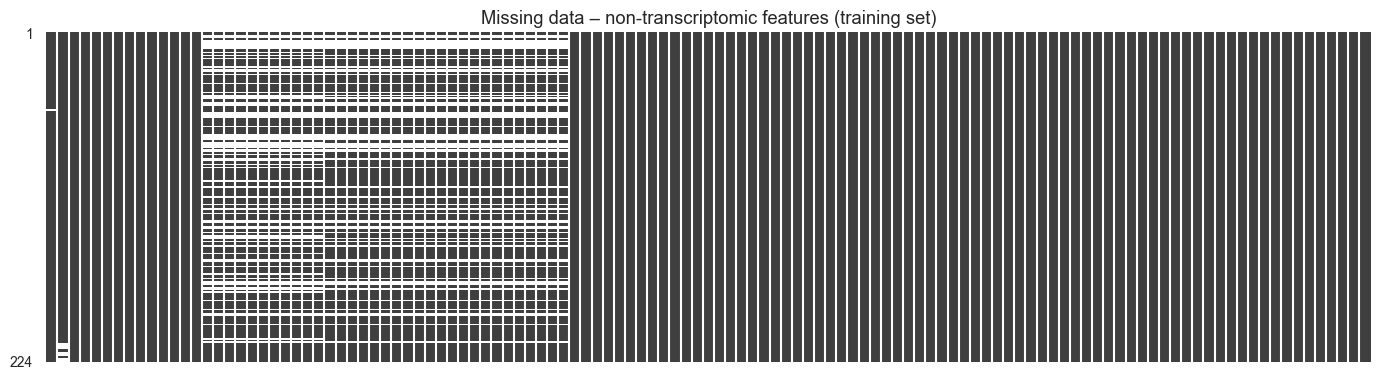

Missing values after MICE: 0


In [60]:
# ── 4.6  Missing value imputation ─────────────────────────────────────────────
X_train_small = pd.concat([
    train_clinic.reset_index(drop=True),
    train_mut.reset_index(drop=True),
    train_deconv.reset_index(drop=True),
    train_pathway_scaled.reset_index(drop=True),
], axis=1)

print(f"Non-transcriptomic features: {X_train_small.shape}")
missing_before = X_train_small.isna().sum().sum()
print(f"Missing values before imputation: {missing_before}")

if missing_before > 0:
    # Visualise missingness
    msno.matrix(X_train_small, figsize=(14, 4), sparkline=False, fontsize=8)
    plt.title('Missing data – non-transcriptomic features (training set)')
    plt.tight_layout(); plt.show()

    # MICE imputation
    kernel = mf.ImputationKernel(X_train_small, random_state=RANDOM_STATE)
    kernel.mice(iterations=5, verbose=False)
    X_train_small = kernel.complete_data()
    print(f"Missing values after MICE: {X_train_small.isna().sum().sum()}")
else:
    kernel = None
    print("No missing values – imputation not needed.")

## 4.7 Feature Selection

### Variance filtering
Remove near-zero-variance features from the combined feature set.

### Embedded selection (L1 regularisation)
Penalised logistic regression with L1 penalty drives irrelevant coefficients
to zero. Features with non-zero coefficients are retained.

In [61]:
# ── 4.7  Feature selection ─────────────────────────────────────────────────────
# ── A.  Variance filter on transcriptomic PCs (done later) ────────────────────

# ── B.  L1 feature selection on non-transcriptomic features ───────────────────
l1 = LogisticRegression(penalty='l1', solver='saga', C=0.1,
                        max_iter=5000, random_state=RANDOM_STATE)
l1.fit(X_train_small, y_train)

l1_mask = l1.coef_[0] != 0
selected_small_cols = X_train_small.columns[l1_mask].tolist()
print(f"L1 selected {len(selected_small_cols)} / {X_train_small.shape[1]} non-transcriptomic features")
print("Selected:", selected_small_cols)

X_train_small_sel = X_train_small[selected_small_cols]

L1 selected 0 / 119 non-transcriptomic features
Selected: []


## 4.8 Dimensionality Reduction – PCA on Transcriptome

With ~20 000 genes remaining, we apply **PCA** to reduce the transcriptomic
block to a manageable number of principal components.

Explained variance (20 PCs): 30.5%


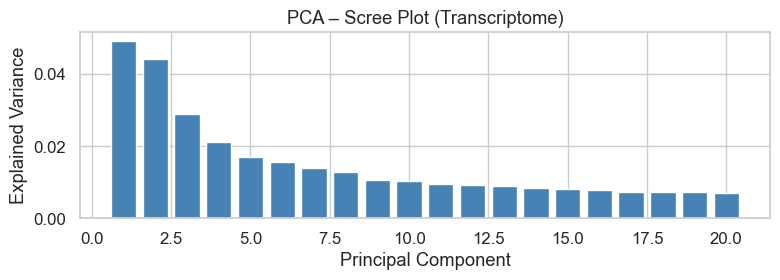

In [62]:
# ── 4.8  PCA on transcriptome ──────────────────────────────────────────────────
N_COMPONENTS = 20
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
train_trans_pca = pd.DataFrame(
    pca.fit_transform(train_trans_scaled),
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)
explained = pca.explained_variance_ratio_
print(f"Explained variance ({N_COMPONENTS} PCs): {explained.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, N_COMPONENTS+1), explained, color='steelblue')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Explained Variance')
ax.set_title('PCA – Scree Plot (Transcriptome)')
plt.tight_layout(); plt.show()

In [63]:
# ── Combine all processed features ────────────────────────────────────────────
X_train_final = pd.concat([
    X_train_small_sel.reset_index(drop=True),
    train_trans_pca.reset_index(drop=True)
], axis=1)

print(f"\n✅ Final training feature matrix: {X_train_final.shape}")
print(f"   Non-transcriptomic features: {X_train_small_sel.shape[1]}")
print(f"   Transcriptomic PCs:          {train_trans_pca.shape[1]}")


✅ Final training feature matrix: (224, 20)
   Non-transcriptomic features: 0
   Transcriptomic PCs:          20


---
# 5. Model Development

We train six classifiers using **Stratified 5-Fold Cross-Validation** on the training set.

## 5.1 Baseline: Penalised Logistic Regression
Provides interpretability and well-calibrated probabilities.

## 5.2 Non-Linear Models
- Decision Tree
- Random Forest
- SVM (RBF kernel)
- XGBoost
- Multi-Layer Perceptron (MLP)

In [64]:
# ── 5.  Model training with Stratified K-Fold CV ─────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        penalty='l2', C=1.0, max_iter=5000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        use_label_encoder=False, eval_metric='logloss', verbosity=0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'pr_auc':   make_scorer(average_precision_score, response_method='predict_proba'),
    'bal_acc':   'balanced_accuracy',
    'f1':        'f1',
    'mcc':       make_scorer(matthews_corrcoef),
}

results = {}
for name, model in models.items():
    cv_res = cross_validate(model, X_train_final, y_train, cv=cv,
                            scoring=scoring, return_train_score=False, n_jobs=-1)
    results[name] = cv_res
    print(f"{name:25s}  PR-AUC={cv_res['test_pr_auc'].mean():.3f}±{cv_res['test_pr_auc'].std():.3f}"
          f"  BalAcc={cv_res['test_bal_acc'].mean():.3f}  F1={cv_res['test_f1'].mean():.3f}"
          f"  MCC={cv_res['test_mcc'].mean():.3f}")

Logistic Regression        PR-AUC=0.174±0.055  BalAcc=0.501  F1=0.044  MCC=-0.004
Decision Tree              PR-AUC=0.158±0.012  BalAcc=0.476  F1=0.144  MCC=-0.050
Random Forest              PR-AUC=0.185±0.053  BalAcc=0.497  F1=0.000  MCC=-0.013
SVM                        PR-AUC=0.246±0.083  BalAcc=0.500  F1=0.000  MCC=0.000
MLP                        PR-AUC=0.214±0.104  BalAcc=0.476  F1=0.073  MCC=-0.042
XGBoost                    PR-AUC=0.167±0.034  BalAcc=0.487  F1=0.000  MCC=-0.042


In [65]:
# ── 6.1  CV results table ─────────────────────────────────────────────────────
rows = []
for name, cv_res in results.items():
    rows.append({
        'Model': name,
        'PR AUC':   f"{cv_res['test_pr_auc'].mean():.3f} ± {cv_res['test_pr_auc'].std():.3f}",
        'Bal. Acc.': f"{cv_res['test_bal_acc'].mean():.3f} ± {cv_res['test_bal_acc'].std():.3f}",
        'F1':        f"{cv_res['test_f1'].mean():.3f} ± {cv_res['test_f1'].std():.3f}",
        'MCC':       f"{cv_res['test_mcc'].mean():.3f} ± {cv_res['test_mcc'].std():.3f}",
    })
results_df = pd.DataFrame(rows)
display(results_df)

,Model,PR AUC,Bal. Acc.,F1,MCC
0,Logistic Regression,0.174 ± 0.055,0.501 ± 0.030,0.044 ± 0.089,-0.004 ± 0.109
1,Decision Tree,0.158 ± 0.012,0.476 ± 0.055,0.144 ± 0.095,-0.050 ± 0.098
2,Random Forest,0.185 ± 0.053,0.497 ± 0.005,0.000 ± 0.000,-0.013 ± 0.026
3,SVM,0.246 ± 0.083,0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
4,MLP,0.214 ± 0.104,0.476 ± 0.080,0.073 ± 0.145,-0.042 ± 0.183
5,XGBoost,0.167 ± 0.034,0.487 ± 0.017,0.000 ± 0.000,-0.042 ± 0.052


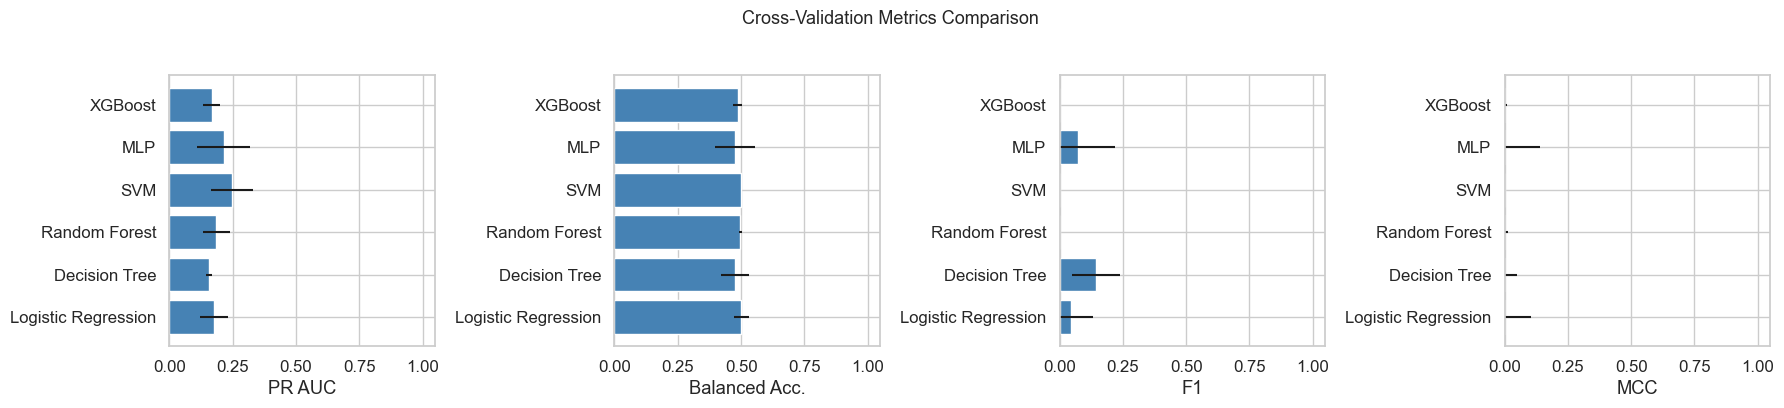

In [66]:
# ── 6.1b  Bar chart comparison ────────────────────────────────────────────────
metrics = ['test_pr_auc', 'test_bal_acc', 'test_f1', 'test_mcc']
metric_labels = ['PR AUC', 'Balanced Acc.', 'F1', 'MCC']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, m, ml in zip(axes, metrics, metric_labels):
    means = [results[n][m].mean() for n in model_names]
    stds  = [results[n][m].std()  for n in model_names]
    ax.barh(model_names, means, xerr=stds, color='steelblue', edgecolor='white')
    ax.set_xlabel(ml); ax.set_xlim(0, 1.05)
plt.suptitle('Cross-Validation Metrics Comparison', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

Best model by PR AUC: SVM


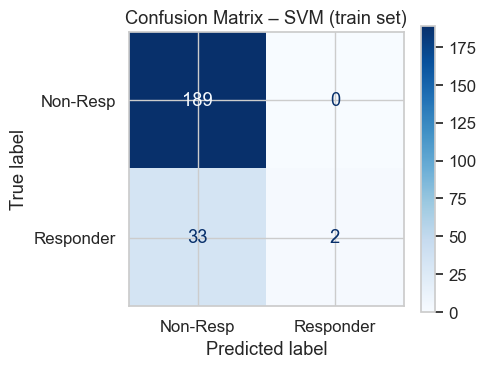

              precision    recall  f1-score   support

    Non-Resp       0.85      1.00      0.92       189
   Responder       1.00      0.06      0.11        35

    accuracy                           0.85       224
   macro avg       0.93      0.53      0.51       224
weighted avg       0.87      0.85      0.79       224



In [67]:
# ── 6.2  Confusion matrix (best model, refit on full train) ───────────────────
best_name = max(results, key=lambda n: results[n]['test_pr_auc'].mean())
print(f"Best model by PR AUC: {best_name}")

best_model = models[best_name]
best_model.fit(X_train_final, y_train)
y_pred_train = best_model.predict(X_train_final)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, ax=ax,
    display_labels=['Non-Resp', 'Responder'], cmap='Blues')
ax.set_title(f'Confusion Matrix – {best_name} (train set)')
plt.tight_layout(); plt.show()
print(classification_report(y_train, y_pred_train, target_names=['Non-Resp','Responder']))

## 6.3 Learning Curve

A learning curve helps diagnose **overfitting** (large train–test gap) and
**underfitting** (both curves plateau at low score).

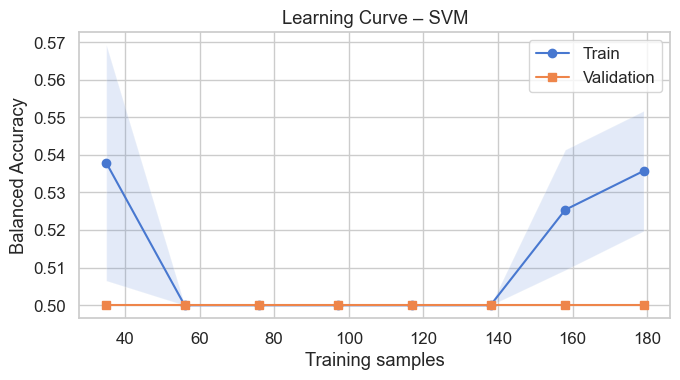

In [68]:
# ── 6.3  Learning curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_final, y_train, cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 8), scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE)

ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
ax.plot(train_sizes, val_scores.mean(axis=1),   's-', label='Validation')
ax.fill_between(train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1), alpha=0.15)
ax.fill_between(train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1), alpha=0.15)
ax.set_xlabel('Training samples'); ax.set_ylabel('Balanced Accuracy')
ax.set_title(f'Learning Curve – {best_name}'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
# 7. Ideas for Model Improvement

Here are strategies you can explore to push performance further:

| Strategy | Description |
|----------|-------------|
| **SMOTE** | Synthetic Minority Oversampling to handle class imbalance (`imblearn.over_sampling.SMOTE`) |
| **Hyperparameter tuning** | `GridSearchCV` or `Optuna` for systematic search |
| **Feature engineering** | Interaction terms, pathway-gene combinations |
| **Ensemble methods** | Stacking, blending multiple base models |
| **Different imputation** | KNN imputation, iterative imputer |

> 💡 **Exercise for students:** Pick one strategy above, implement it,
> and compare CV metrics before vs. after.

---
# 8. Biological Interpretation (if time allows)

## 8.1 Global Feature Importance

Examining which features most influence the model's predictions can
yield biological insights (e.g. key immune cell types, driver mutations).

In [69]:
# ── 8.1  Feature importance ────────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None
    print("Model does not expose feature importances directly.")

if importances is not None:
    feat_imp = pd.Series(importances, index=X_train_final.columns)
    top20 = feat_imp.nlargest(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    top20.sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Importance'); ax.set_title(f'Top 20 Features – {best_name}')
    plt.tight_layout(); plt.show()

Model does not expose feature importances directly.


---
# 9. Save Model & Preprocessing Artifacts

All fitted objects are saved so the **Deployment Notebook** can apply the
exact same pipeline to the held-out test set.

In [70]:
# ── Save everything ───────────────────────────────────────────────────────────
os.makedirs('artifacts', exist_ok=True)

artifacts = {
    'model':             best_model,
    'model_name':        best_name,
    'trans_scaler':      trans_scaler,
    'pathway_scaler':    pathway_scaler,
    'clinical_scaler':   clinical_scaler,
    'pca':               pca,
    'keep_genes':        keep_genes,
    'mutation_cols':      mutation_cols,
    'cell_type_cols':     cell_type_cols,
    'quality_cols':       quality_cols,
    'clinical_encoded_cols': clinical_encoded_cols,
    'num_cols':           num_cols,
    'cat_cols':           cat_cols,
    'clinical_feature_cols': clinical_feature_cols,
    'selected_small_cols': selected_small_cols,
    'n_pca_components':   N_COMPONENTS,
    'mice_kernel':        kernel,
    'l1_selector':        l1,
}
joblib.dump(artifacts, 'artifacts/pipeline_artifacts.joblib')
print("✅ Artifacts saved to artifacts/pipeline_artifacts.joblib")
print(f"   Model: {best_name}")
print(f"   Features: {X_train_final.shape[1]} total")

✅ Artifacts saved to artifacts/pipeline_artifacts.joblib
   Model: SVM
   Features: 20 total
